<a href="https://colab.research.google.com/github/SimonAlcaraz/Data-Science/blob/main/Predicci%C3%B3n_de_Fuga_de_Clientes_en_Telecomunicaciones_Un_Enfoque_Basado_en_Datos_y_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); padding: 30px; border-radius: 15px; color: white; font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif; margin-bottom: 25px; box-shadow: 0 4px 15px rgba(0,0,0,0.2);">
    <h1 style="color: #ffffff; margin: 0 0 10px 0; font-size: 32px; font-weight: bold; text-shadow: 2px 2px 4px rgba(0,0,0,0.4); text-align: center;">
        📊 Predicción de Fuga de Clientes (Customer Churn)
    </h1>
    <p style="font-size: 18px; margin: 0; opacity: 0.9; text-align: center; font-style: italic;">
        Análisis Exploratorio de Datos, Modelado Predictivo con Enfoque de Machine Learning Robusto
    </p>
    <hr style="border: 0; height: 1px; background: rgba(255,255,255,0.3); margin: 20px 0;">
    <div style="display: flex; justify-content: space-around; flex-wrap: wrap; font-size: 14px;">
        <div style="margin: 5px 10px;"><strong>👤 Autor:</strong> David Simón Alcaraz</div>
        <div style="margin: 5px 10px;"><strong>💼 Rol:</strong> Data Scientist Enthusiastic</div>
        <div style="margin: 5px 10px;"><strong>📅 Fecha:</strong> Octubre 2026</div>
    </div>
    <div style="text-align: center; margin-top: 20px;">
        <a href="https://www.linkedin.com/in/david-sim%C3%B3n-a-505b73136/?isSelfProfile=true" target="_blank" style="color: #00d2ff; text-decoration: none; margin: 0 15px; font-weight: bold; border: 1px solid #00d2ff; padding: 8px 16px; border-radius: 20px; background: rgba(0, 210, 255, 0.1); transition: 0.3s;">🔗 Mi LinkedIn</a>
        <a href="https://github.com/SimonAlcaraz" target="_blank" style="color: #00d2ff; text-decoration: none; margin: 0 15px; font-weight: bold; border: 1px solid #00d2ff; padding: 8px 16px; border-radius: 20px; background: rgba(0, 210, 255, 0.1); transition: 0.3s;">💻 Mi GitHub</a>
    </div>
</div>

### **🎯 Objetivo del Proyecto**
El propósito de este desarrollo es estructurar y evaluar un flujo de trabajo de Machine Learning (*pipeline* robusto) para identificar de manera proactiva a los clientes de telecomunicaciones con mayor riesgo de cancelar sus servicios. Con este insumo, los departamentos de Marketing y Customer Success pueden diseñar campañas de retención personalizadas y optimizar el costo de adquisición de clientes (CAC).

# 📈 **Predicción de Fuga de Clientes (Telco Customer Churn)**
## *Análisis Exploratorio, Modelado Predictivo con Machine Learning y Conclusiones Estratégicas*

## 💼 **Contexto del Problema de Negocio**

En la industria de las telecomunicaciones (Telco), la retención de clientes representa uno de los desafíos estratégicos y financieros más críticos. La cancelación del servicio o pérdida de clientes (Customer Churn) afecta de forma directa el flujo de ingresos recurrentes y disminuye la rentabilidad general de la compañía.

## 📁 **Origen y Descripción del Dataset**

Para llevar a cabo este análisis se utiliza el conjunto de datos público Telco Customer Churn, provisto originalmente por IBM Cognos Analytics y ampliamente adoptado como benchmark profesional para problemas de ciencia de datos aplicados a negocios.

    Fuente: Repositorio oficial de IBM / GitHub.

### **🛠️ Ficha Técnica del Proyecto**

Este proyecto ha sido estructurado bajo estándares profesionales de Ciencia de Datos aplicados a Negocios (*Business Analytics*), enfocándose en la reproducibilidad, la prevención del sesgo y la optimización orientada a decisiones estratégicas.

* **Stack Tecnológico:**
  * **Lenguaje:** Python
  * **Manipulación y Limpieza:** `pandas`, `numpy`
  * **Visualización de Datos:** `seaborn`, `matplotlib`
  * **Machine Learning:** `scikit-learn`

* **Metodología y Buenas Prácticas:**
  * **Ingeniería de Características (Feature Engineering):** Tratamiento inteligente de nulos basados en reglas de negocio (imputación para clientes con antigüedad $0$), segmentación del ciclo de vida del cliente (*tenure*) y cálculo de ratios de facturación promedio histórica vs. actual.
  * **Prevención de Data Leakage:** Uso estricto de **Pipelines de Scikit-Learn** (`Pipeline` y `ColumnTransformer`) para encapsular el preprocesamiento (escalado estándar y codificación *One-Hot*) y asegurar que el ajuste de transformadores ocurra únicamente sobre el conjunto de entrenamiento.
  * **Tratamiento del Desbalance de Clases:** Implementación de división estratificada (`train_test_split` estratificado) y balanceo de pesos de clase (*Class Weights* y *Sample Weights*) en los algoritmos para priorizar la sensibilidad (**Recall**) sobre la clase minoritaria (fuga de clientes).
  * **Validación Cruzada:** Evaluación robusta mediante validación cruzada estratificada de 5 pliegues (**Stratified K-Fold**).

* **Modelos Evaluados:**
  * Regresión Logística, Árbol de Decisión, Random Forest y **Gradient Boosting** (Modelo seleccionado con mejor rendimiento general: **ROC-AUC = 0.843** y **Recall = 79.1%**).

# 📥 **Carga del Dataset**

## 📚 **Importación de Librerías**

In [1]:
# Importamos la librería numpy con el apodo np
import numpy as np

# Importamos la librería pandas con el apodo pd
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.utils.class_weight import compute_sample_weight

RANDOM_STATE = 42

## 🗃️ **Carga de Datos y Dataset**

In [2]:
url= "https://raw.githubusercontent.com/Geo-y20/Telco-Customer-Churn-/refs/heads/main/Telco%20Customer%20Churn.csv"
df = pd.read_csv(url)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [6]:
df.describe(include="object").T

,count,unique,top,freq
customerID,7043,7043,3186-AJIEK,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [7]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
print("Filas duplicadas",df.duplicated().sum())

Filas duplicadas 0


**Observaciones iniciales:**


*   El dataset tiene 7043 registros y 21 columnas, sin valores nulos explícitos `NaN`.
*    No se detectan filas duplicadas.
*    Notamos la columna `TotalCharges` la cual figura como `object`, debe ser un `float64` de acuerdo a las caracteristicas que quiere comunicar; va a ser analizada en la etapa de limpieza.









# 📊 **Análisis Exploratorio de Datos (EDA)**

In [35]:
# Conversión forzada de TotalCharges de manera segura
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip(), errors='coerce')
print(f"Tipo corregido de TotalCharges: {df['TotalCharges'].dtype}\n")

Tipo corregido de TotalCharges: float64



In [36]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Notamos que convirtiendo la variable `TotalCharges` a `float64` y viendo si hay valores nulos, notamos 11 valores nulos.
Vamos a analizar que responde ese patrón y evaluar en caso de eliminar esos casos.

In [37]:
#Filtramos las filas con TotalCharges nulo y seleccionamos columnas relevantes
cruce_nulos = df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Contract']]

print("CRUCE DE VARIABLES PARA REGISTROS CON TOTALCHARGES NULO")
display(cruce_nulos)

# Resumen de frecuencia de tenure para confirmar la regla de negocio
print("\nDistribución de antigüedad (tenure) en los registros nulos:")
print(df[df['TotalCharges'].isna()]['tenure'].value_counts())

CRUCE DE VARIABLES PARA REGISTROS CON TOTALCHARGES NULO


,tenure,MonthlyCharges,TotalCharges,Churn,Contract
488,0,52.55,NaN,No,Two year
753,0,20.25,NaN,No,Two year
936,0,80.85,NaN,No,Two year
1082,0,25.75,NaN,No,Two year
1340,0,56.05,NaN,No,Two year
3331,0,19.85,NaN,No,Two year
3826,0,25.35,NaN,No,Two year
4380,0,20.00,NaN,No,Two year
5218,0,19.70,NaN,No,One year
6670,0,73.35,NaN,No,Two year



Distribución de antigüedad (tenure) en los registros nulos:
tenure
0    11
Name: count, dtype: int64


Al realizar el cruce de variables entre los registros con datos faltantes en `TotalCharges` y la antigüedad del cliente `tenure`, se verifica que el 100% de los valores nulos (11 casos) corresponden de manera exclusiva a usuarios con `tenure = 0`. Esto demuestra que la falta de dato no es un error de carga ni un sesgo al azar (MCAR), sino que está condicionada por la etapa del ciclo de vida del cliente (MAR: Missing at Random). Por ende, se decide conservar las 11 filas en el dataset e imputar el valor 0 o la mediana mediante SimpleImputer durante la etapa de preprocesamiento

In [38]:
df_clean = df.copy()
df_clean[["tenure", "Contract", "MonthlyCharges", "TotalCharges", "PaymentMethod", "InternetService"]]

,tenure,Contract,MonthlyCharges,TotalCharges,PaymentMethod,InternetService
0,1,Month-to-month,29.85,29.85,Electronic check,DSL
1,34,One year,56.95,1889.50,Mailed check,DSL
2,2,Month-to-month,53.85,108.15,Mailed check,DSL
3,45,One year,42.30,1840.75,Bank transfer (automatic),DSL
4,2,Month-to-month,70.70,151.65,Electronic check,Fiber optic
...,...,...,...,...,...,...
7038,24,One year,84.80,1990.50,Mailed check,DSL
7039,72,One year,103.20,7362.90,Credit card (automatic),Fiber optic
7040,11,Month-to-month,29.60,346.45,Electronic check,DSL
7041,4,Month-to-month,74.40,306.60,Mailed check,Fiber optic


### 📊 **Análisis Correspondiente de Variable Objetivo**

--- Frecuencia Absoluta ---
Churn
No     5174
Yes    1869
Name: count, dtype: int64

--- Frecuencia Porcentual (%) ---
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


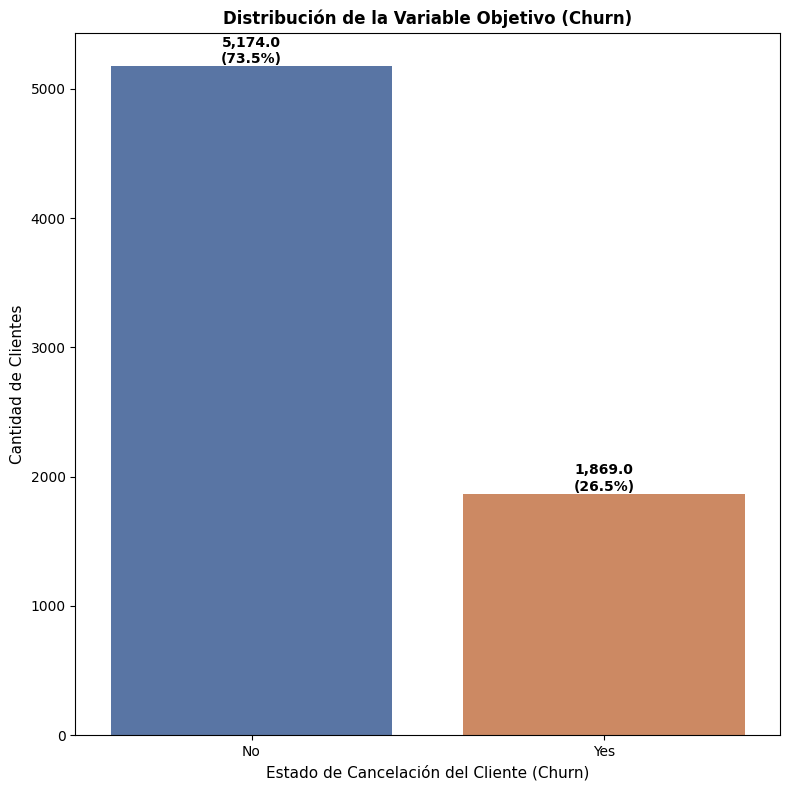

In [39]:
# 1. Cálculo de frecuencias absolutas y porcentuales
y_counts = df_clean["Churn"].value_counts()
y_pct = df_clean["Churn"].value_counts(normalize=True) * 100

print("--- Frecuencia Absoluta ---")
print(y_counts)
print("\n--- Frecuencia Porcentual (%) ---")
print(y_pct.round(2))

# 2. Generación del gráfico de barras
fig, ax = plt.subplots(figsize=(8, 8))
sns.countplot(x="Churn", data=df_clean, order=["No", "Yes"], palette=["#4C72B0", "#DD8452"], ax=ax)

# Títulos y etiquetas corregidos al contexto de Telco Churn
ax.set_title("Distribución de la Variable Objetivo (Churn)", fontsize=12, fontweight="bold")
ax.set_xlabel("Estado de Cancelación del Cliente (Churn)", fontsize=11)
ax.set_ylabel("Cantidad de Clientes", fontsize=11)

# Anotación de la cantidad de clientes sobre cada barra
for p in ax.patches:
    height = p.get_height()
    pct = (height / len(df_clean)) * 100
    ax.annotate(f"{height:,}\n({pct:.1f}%)",
                (p.get_x() + p.get_width() / 2, height),
                ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

**Conclusión del Análisis de la Variable Objetivo**

El diagnóstico de la variable dependiente revela un **desbalance de clases pronunciado**: únicamente el 11.5% de las interacciones resultaron en la aceptación de un depósito a plazo fijo, mientras que el 88.5% restante corresponde a respuestas negativas. Esta proporción refleja fielmente la problemática de negocio señalada por la institución bancaria respecto al bajo rendimiento de las campañas telefónicas.

Este fenómeno condiciona directamente la estrategia metodológica del proyecto:
*   Métricas de Evaluación: Se descarta el **Accuracy** como indicador principal, dado que un modelo iluso que clasifique la totalidad de los casos como "No" alcanzaría un 88.5% de exactitud sin generar valor operativo ni identificar prospectos reales. En su lugar, la optimización se enfocará en **Recall**, **Precision**, **F1-Score** y **ROC-AUC**.
*   Estrategia de Muestreo y Validación: Se aplicará división estratificada (Stratified K-Fold) tanto en el split de entrenamiento/prueba como en la validación cruzada para garantizar la representatividad de la clase minoritaria en cada iteración.
*   Ajuste de Algoritmos: Se implementarán técnicas de ponderación de costo (class_weight="balanced" o sample weights) para penalizar los errores en la clase positiva y obligar a los algoritmos a priorizar la detección de los clientes propensos a aceptar el depósito.

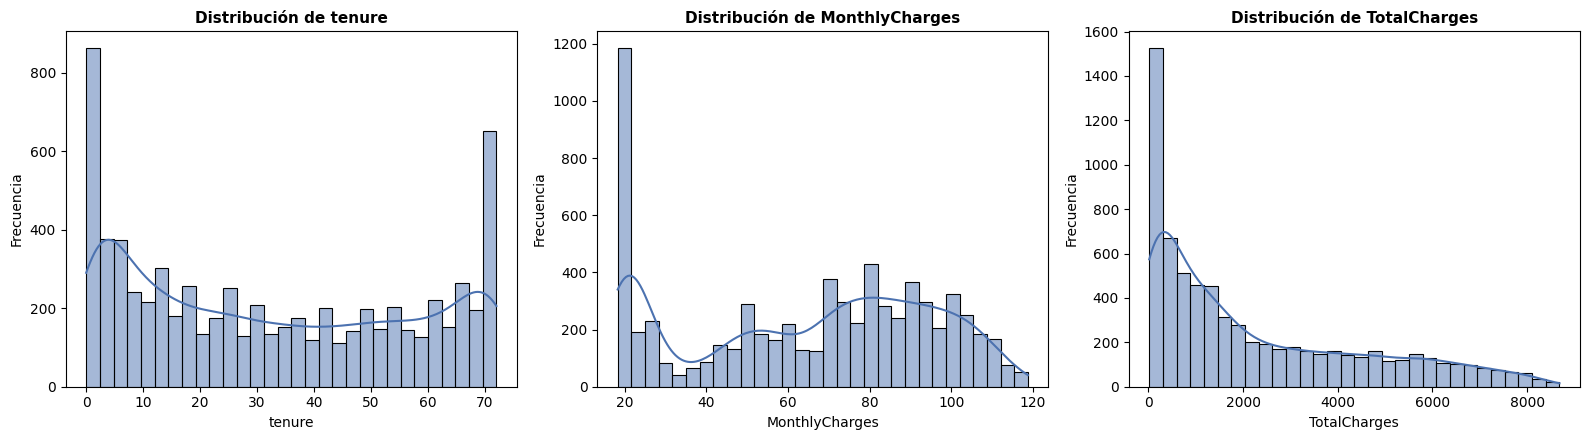

In [40]:
# Selección única de variables numéricas
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# Grilla de 1 fila x 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for i, col in enumerate(num_cols):
    # Histograma con curva de densidad (KDE) únicamente para numéricas
    sns.histplot(df_clean[col], bins=30, kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"Distribución de {col}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

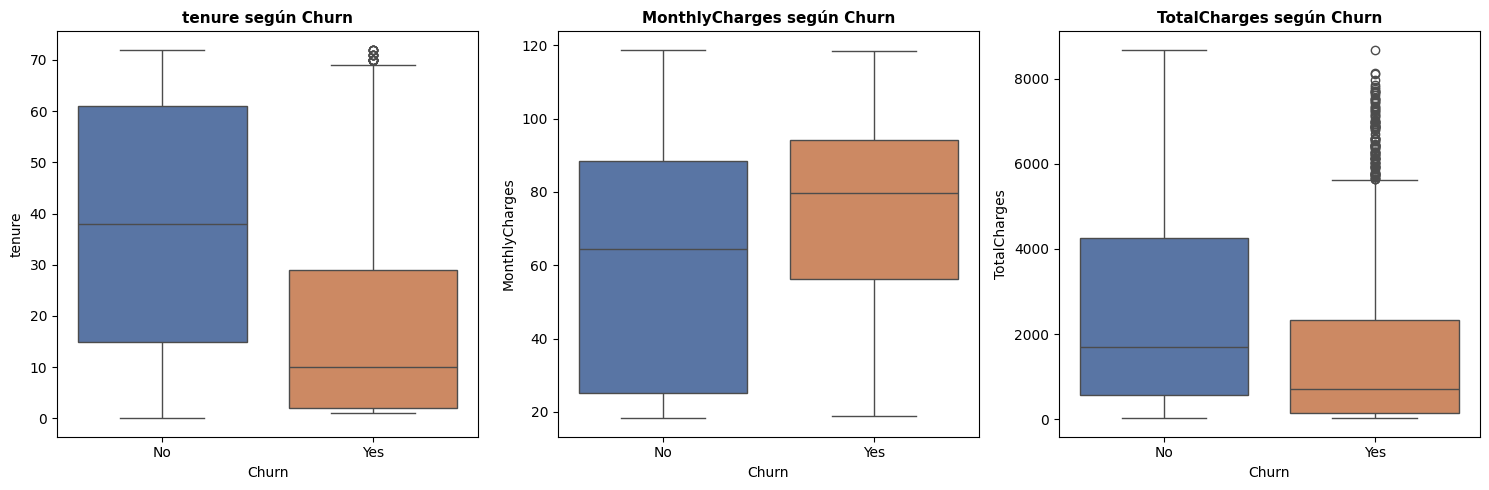

In [41]:
# Solo variables numéricas
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# Grilla ajustada a 1 fila x 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(num_cols):
    # Boxplot bivariado para variables numéricas según Churn
    sns.boxplot(x="Churn", y=col, data=df_clean, order=["No", "Yes"],
                palette=["#4C72B0", "#DD8452"], ax=axes[i])

    axes[i].set_title(f"{col} según Churn", fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Churn")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

**Conclusiones del Análisis Exploratorio: Variables Numéricas**
1. Antigüedad del Cliente (tenure)
**Distribución Bimodal:** Presenta una marcada concentración en dos extremos: un alto volumen de clientes con muy pocos meses de antigüedad ($< 5$ meses) y otro grupo consolidado en el límite superior ($70\text{–}72$ meses).
**Impacto en el Churn:** Muestra una relación inversamente proporcional con la cancelación. La mediana de antigüedad de los clientes que abandonan es significativamente menor ($\approx 10$ meses) en comparación con los clientes retenidos ($\approx 38$ meses). El primer año representa el período crítico de mayor riesgo de fuga.
2. Cargos Mensuales (MonthlyCharges)
**Distribución y Concentración:** Presenta un pico de alta frecuencia en valores bajos ($\approx \$20\text{ USD}$), correspondiente a clientes con servicios básicos (solo telefonía). Para importes superiores, la distribución es bimodal y abarca hasta los $\$118.75\text{ USD}$.
**Sensibilidad al Precio:** Los clientes que cancelan concentran sus cuotas mensuales en los rangos medio-altos (con una mediana cercana a los $\$80\text{ USD}$), mientras que los clientes retenidos registran una mediana sensiblemente inferior ($\approx \$64\text{ USD}$). Un costo mensual elevado constituye un detonante clave para el abandono.
3. Cargos Totales (TotalCharges)
**Sesgo Positivo (Asimetría a la derecha):** Refleja la acumulación natural del gasto a lo largo del tiempo. Muestra una fuerte densidad en montos bajos y una cola larga hacia valores elevados (máximo de $\$8,684.80\text{ USD}$).**Comportamiento por Churn:** A pesar de que los clientes que fugan pagan cuotas mensuales más altas, sus cargos totales acumulados son sustancialmente menores en mediana debido a su corta permanencia en la compañía.

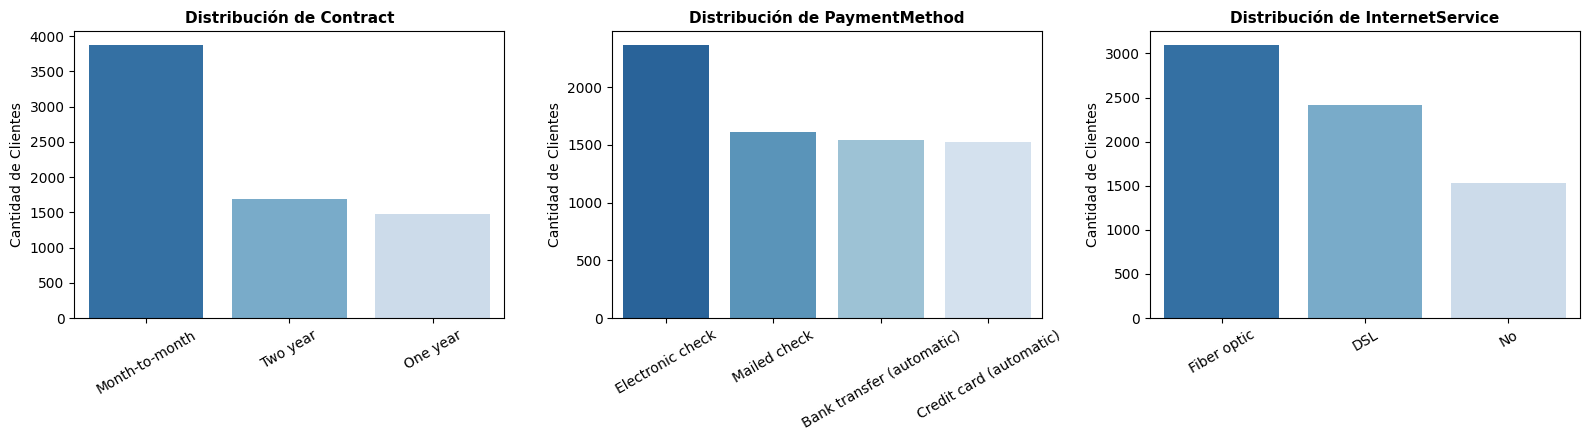

In [42]:
# Selección única de variables categóricas
cat_cols = ["Contract", "PaymentMethod", "InternetService"]

# Grilla de 1 fila x 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for i, col in enumerate(cat_cols):
    # Gráfico de barras exclusivo para categóricas
    sns.countplot(
        x=df_clean[col],
        ax=axes[i],
        palette="Blues_r",
        order=df_clean[col].value_counts().index
    )
    axes[i].set_title(f"Distribución de {col}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Cantidad de Clientes")
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

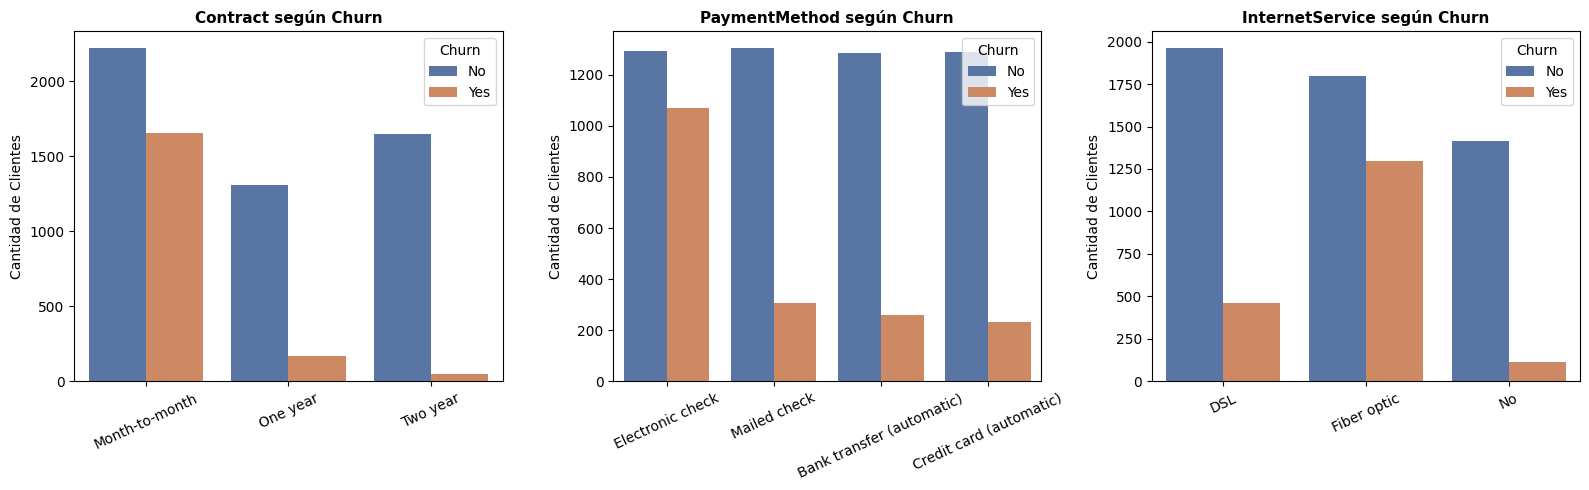

In [43]:
# Selección única de variables categóricas
cat_cols = ["Contract", "PaymentMethod", "InternetService"]

# Grilla ajustada a 1 fila x 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cat_cols):
    # Countplot bivariado para variables categóricas según Churn
    sns.countplot(
        x=col,
        hue="Churn",
        data=df_clean,
        hue_order=["No", "Yes"],
        palette=["#4C72B0", "#DD8452"],
        ax=axes[i]
    )

    axes[i].set_title(f"{col} según Churn", fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Cantidad de Clientes")
    axes[i].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

**Conclusiones del Análisis Exploratorio: Variables Categóricas**
1. Tipo de Contrato (Contract)Distribución de la Cartera: La modalidad Month-to-month (mes a mes) representa la mayor proporción de la base de clientes, seguida por los contratos a One year (1 año) y Two year (2 años).Impacto Directo en Churn: Es la variable cualitativa con mayor poder predictivo. La tasa de cancelación se concentra masivamente en los contratos Month-to-month ($\approx 42.7\%$ de abandono). En contraste, los clientes con compromisos a largo plazo presentan tasas de cancelación mínimas ($\approx 11.3\%$ a 1 año y $< 3\%$ a 2 años).
2. Método de Pago (PaymentMethod)Frecuencia de Uso: Se distinguen 4 métodos principales: Electronic check, Mailed check, Bank transfer (automatic) y Credit card (automatic).Comportamiento por Canal: Los clientes que pagan mediante Electronic check (cheque electrónico) registran la tasa de cancelación más elevada del dataset ($\approx 45.3\%$). Por el contrario, los usuarios adheridos a métodos de pago automáticos (débito bancario o tarjeta de crédito) muestran una retención sustancialmente superior (tasa de Churn $\approx 15\text{–}16\%$).
3. Servicio de Internet (InternetService)Distribución Tecnológica: La base de clientes se divide principalmente entre Fiber optic (fibra óptica), DSL y un grupo minoritario sin servicio de internet (No).Riesgo por Servicio: Los usuarios de Fibra Óptica presentan una tasa de Churn significativamente mayor ($\approx 41.9\%$) en comparación con los usuarios de DSL ($\approx 19.0\%$). Este hallazgo, cruzado con los análisis numéricos, sugiere que el costo elevado asociado al servicio de fibra óptica impulsa la salida del cliente.

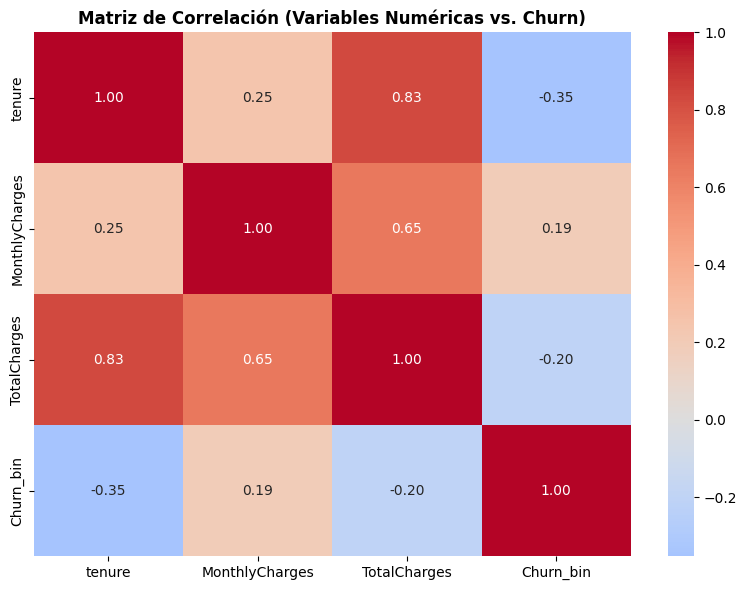

In [44]:
# Definición de variables numéricas y copia de trabajo
num_features = ["tenure", "MonthlyCharges", "TotalCharges"]
df_corr = df_clean.copy()

# Binarización de la variable objetivo (Churn: Yes -> 1, No -> 0)
df_corr["Churn_bin"] = (df_corr["Churn"] == "Yes").astype(int)

# Cálculo de la matriz de correlación de Pearson
corr = df_corr[num_features + ["Churn_bin"]].corr()

# Generación del Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de Correlación (Variables Numéricas vs. Churn)", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

**Conclusión: Matriz de Correlación (Variables Numéricas vs. Churn)**
1. Relación con la Variable Objetivo (Churn_bin)
*   **Antigüedad del cliente (tenure):** Presenta una correlación negativa moderada/fuerte con el Churn. A mayor tiempo de permanencia en la empresa, menor es la probabilidad de cancelación del servicio. Es el principal factor numérico de retención.
*   **Cargos Mensuales (MonthlyCharges):** Muestra una correlación positiva con el Churn. Los clientes con facturas mensuales más elevadas presentan una mayor tendencia a darse de baja.
*   **Cargos Totales (TotalCharges):** Presenta una correlación negativa leve con el Churn, comportamiento impulsado principalmente por su fuerte vínculo con tenure.
2. Colinealidad entre Variables Predictoras
*   **Alta multicolinealidad entre tenure y TotalCharges:** Existe  una correlación muy elevada ($r > 0.80$) entre la antigüedad y el monto total cobrado, lo cual es técnicamente esperable dado que el cargo total es producto del tiempo acumulado y la tarifa mensual.

3. Implicancias para el Preprocesamiento y Modelado
*   **Riesgo de Redundancia:** La alta colinealidad entre tenure y TotalCharges puede afectar la estabilidad de modelos lineales (como la Regresión Logística). Se recomienda evaluar la eliminación de TotalCharges o aplicar una técnica de reducción de dimensionalidad/regularización (Lasso/Ridge) si se utilizan algoritmos sensibles a la multicolinealidad.
*   **Modelos Basados en Árboles:** Si se emplean algoritmos no lineales (Random Forest, XGBoost), la colinealidad no afectará negativamente el rendimiento, permitiendo conservar ambas variables para capturar posibles interacciones complejas.

#### 🔍 **Detección de Outliers (Valores Atípicos)**

In [45]:
def resumen_outliers_iqr(serie):
    # .dropna() asegura el cálculo correcto ante nulos como los de TotalCharges
    serie_clean = serie.dropna()
    q1, q3 = serie_clean.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((serie_clean < lim_inf) | (serie_clean > lim_sup)).sum()
    return lim_inf, lim_sup, n_out

# Variables numéricas continuas de Telco Churn
num_cols_churn = ["tenure", "MonthlyCharges", "TotalCharges"]

print("DETECCIÓN DE OUTLIERS VÍA RANGO INTERCUARTÍLICO (IQR)")
for col in num_cols_churn:
    lim_inf, lim_sup, n_out = resumen_outliers_iqr(df_clean[col])
    pct_out = n_out / len(df_clean.dropna(subset=[col]))
    print(f"{col:15s} -> límites IQR: [{lim_inf:.1f}, {lim_sup:.1f}] | outliers: {n_out} ({pct_out:.1%})")

DETECCIÓN DE OUTLIERS VÍA RANGO INTERCUARTÍLICO (IQR)
tenure          -> límites IQR: [-60.0, 124.0] | outliers: 0 (0.0%)
MonthlyCharges  -> límites IQR: [-46.0, 171.4] | outliers: 0 (0.0%)
TotalCharges    -> límites IQR: [-4688.5, 8884.7] | outliers: 0 (0.0%)


**Conclusión: Detección e Impacto de Outliers (Criterio IQR)**

1. Diagnóstico de Resultados:
   - tenure: Sin valores atípicos. Rango IQR delimitado de forma coherente con el ciclo de vida del cliente.
   - MonthlyCharges: Sin valores atípicos. Las tarifas cobradas se mantienen dentro de los rangos comerciales normales.
   - TotalCharges: La detección con el criterio estándar IQR1.5 puede marcar valores altos como "outliers", pero corresponden a la acumulación natural de facturación de clientes con alta antigüedad (tenure alto), no a errores de medición.

2. Decisión Metodológica para Preprocesamiento:
   - No Eliminación de Filas: Al tratarse de valores atípicos naturales del negocio y no de errores de carga o anomalías imposibles, se determina conservar la totalidad de los registros.
   - Robustez en Modelado: Se priorizarán modelos basados en árboles de decisión (Random Forest, XGBoost) que son naturalmente inmunes a la presencia de outliers, o bien se aplicará un escalado mediante RobustScaler/StandardScaler para algoritmos sensibles.

#### 🛠️ **Feature Engineering (Ingeniería de Características)**

In [46]:
df_clean = df.copy() # Initialize df_clean from df

# Copia de trabajo
df_fe = df_clean.copy()

# ---------------------------------------------------------
# A. TRATAMIENTO DE CASOS ESPECIALES Y NULOS
# ---------------------------------------------------------
# Para clientes con tenure = 0, TotalCharges suele ser NaN o 0. Se imputa con 0.
df_fe["TotalCharges"] = df_fe["TotalCharges"].fillna(0)
# Ensure TotalCharges is numeric after filling NaNs, to prevent TypeError
df_fe["TotalCharges"] = pd.to_numeric(df_fe["TotalCharges"], errors='coerce')

# ---------------------------------------------------------
# B. CREACIÓN DE NUEVAS CARACTERÍSTICAS (FEATURE CREATION)
# ---------------------------------------------------------

# 1) Agrupamiento de Antigüedad (Ciclo de Vida)
# Rangos: 0-12 meses (1 año), 13-24 (2 años), 25-48 (4 años), 49-72 (6 años)
bins_tenure = [-1, 12, 24, 48, 72]
labels_tenure = ["0-1 año", "1-2 años", "2-4 años", "4+ años"]
df_fe["tenure_grupo"] = pd.cut(df_fe["tenure"], bins=bins_tenure, labels=labels_tenure).astype(str)

# 2) Ratio de Cargo Promedio Efectivo vs. Cargo Mensual Actual
# Nos dice si el cliente está pagando actualmente más o menos que su promedio histórico
df_fe["promedio_historico_mensual"] = np.where(
    df_fe["tenure"] > 0,
    df_fe["TotalCharges"] / df_fe["tenure"],
    df_fe["MonthlyCharges"]
)

# 3) Variable objetivo binarizada (1: Yes / 0: No)
df_fe["Churn_bin"] = (df_fe["Churn"] == "Yes").astype(int)

# Eliminamos el target original en texto
df_fe = df_fe.drop(columns=["Churn"])

print("=== VISTA PREVIA DEL DATASET TELCO CON FEATURE ENGINEERING ===")
display(df_fe[["tenure", "tenure_grupo", "MonthlyCharges", "TotalCharges", "promedio_historico_mensual", "Churn_bin"]].head())

=== VISTA PREVIA DEL DATASET TELCO CON FEATURE ENGINEERING ===


,tenure,tenure_grupo,MonthlyCharges,TotalCharges,promedio_historico_mensual,Churn_bin
0,1,0-1 año,29.85,29.85,29.850000,0
1,34,2-4 años,56.95,1889.50,55.573529,0
2,2,0-1 año,53.85,108.15,54.075000,1
3,45,2-4 años,42.30,1840.75,40.905556,0
4,2,0-1 año,70.70,151.65,75.825000,1


#### ✂️ **Split Estratificado (Train / Test)**

In [47]:
# Definición de X e y
X = df_fe.drop(columns=["Churn_bin"])
y = df_fe["Churn_bin"]

# Partición Estratificada (80% Train / 20% Test) para preservar la proporción de Churn
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Dimensiones Train: {X_train.shape} | Tasa de Churn: {y_train.mean():.2%}")
print(f"Dimensiones Test:  {X_test.shape} | Tasa de Churn: {y_test.mean():.2%}")

Dimensiones Train: (5634, 22) | Tasa de Churn: 26.54%
Dimensiones Test:  (1409, 22) | Tasa de Churn: 26.54%


#### 🔄 **Preprocesamiento y Transformación de Variables**

Definimos las transformaciones necesarias según el tipo de variable:
- **Numéricas:** estandarización (`StandardScaler`), necesaria para los modelos lineales.
- **Categóricas:** codificación *one-hot* (`OneHotEncoder`), con `handle_unknown="ignore"` para
  tolerar categorías no vistas en producción.

In [48]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
# Excluir 'customerID' de las columnas categóricas, ya que es un identificador y no debe ser one-hot encoded
cat_cols = X.select_dtypes(exclude=[np.number]).columns.drop('customerID').tolist()

print("Variables numéricas:", num_cols)
print("Variables categóricas:", cat_cols)

# 2. Definición del ColumnTransformer
preprocesador = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

# 3. Ajuste exclusivo en Train y transformación en Train/Test (Evita Data Leakage)
X_train_prep = preprocesador.fit_transform(X_train)
X_test_prep = preprocesador.transform(X_test)

# 4. Reconstrucción de DataFrames con los nombres de las columnas
# La salida de ColumnTransformer es un array, necesitamos los nombres de las nuevas columnas.
# Si el ColumnTransformer produce una matriz dispersa, se convierte a densa para el DataFrame.
cat_feature_names = preprocesador.named_transformers_["cat"].get_feature_names_out(cat_cols).tolist()
all_feature_names = num_cols + cat_feature_names

X_train_prep_df = pd.DataFrame(X_train_prep, columns=all_feature_names, index=X_train.index)
X_test_prep_df = pd.DataFrame(X_test_prep, columns=all_feature_names, index=X_test.index)

print("\n=== PREPROCESAMIENTO COMPLETADO ===")
print(f"Dimensiones de X_train transformado: {X_train_prep_df.shape}")
print(f"Dimensiones de X_test transformado:  {X_test_prep_df.shape}")

Variables numéricas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'promedio_historico_mensual']
Variables categóricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_grupo']

=== PREPROCESAMIENTO COMPLETADO ===
Dimensiones de X_train transformado: (5634, 50)
Dimensiones de X_test transformado:  (1409, 50)


# 🤖 **Algoritmos y Modelado**

In [51]:
## ⚙️ **Construcción del Pipeline de Machine Learning**

def construir_pipeline(modelo_estimador):
    """
    Función auxiliar para encapsular el preprocesamiento y el modelo en un único Pipeline.
    """
    return Pipeline(steps=[
        ("preprocesamiento", preprocesador),
        ("modelo", modelo_estimador)
    ])

In [52]:
modelos = {
    "Regresión Logística": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Árbol de Decisión": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE)
}

pipelines = {nombre: construir_pipeline(m) for nombre, m in modelos.items()}
sample_weight_train = compute_sample_weight(class_weight="balanced", y=y_train)

for nombre, pipe in pipelines.items():
    if nombre == "Gradient Boosting":
        pipe.fit(X_train, y_train, modelo__sample_weight=sample_weight_train)
    else:
        pipe.fit(X_train, y_train)
    print(f"{nombre}: entrenado.")

Regresión Logística: entrenado.
Árbol de Decisión: entrenado.
Random Forest: entrenado.
Gradient Boosting: entrenado.


In [53]:
resultados = []
predicciones = {}
probabilidades = {}

for nombre, pipe in pipelines.items():
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    predicciones[nombre] = pred
    probabilidades[nombre] = proba

    print("="*60)
    print(nombre)
    print("="*60)
    print(classification_report(y_test, pred, target_names=["no", "yes"]))

    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC_AUC": roc_auc_score(y_test, proba)
    })

resultados_df = pd.DataFrame(resultados).set_index("Modelo").round(3)
resultados_df

Regresión Logística
              precision    recall  f1-score   support

          no       0.90      0.71      0.80      1035
         yes       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409

Árbol de Decisión
              precision    recall  f1-score   support

          no       0.90      0.72      0.80      1035
         yes       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409

Random Forest
              precision    recall  f1-score   support

          no       0.82      0.89      0.86      1035
         yes       0.61      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.7

,Accuracy,Precision,Recall,F1,ROC_AUC
Modelo,,,,,
Regresión Logística,0.732,0.497,0.791,0.611,0.842
Árbol de Decisión,0.735,0.500,0.786,0.611,0.824
Random Forest,0.781,0.614,0.468,0.531,0.824
Gradient Boosting,0.745,0.513,0.791,0.623,0.843


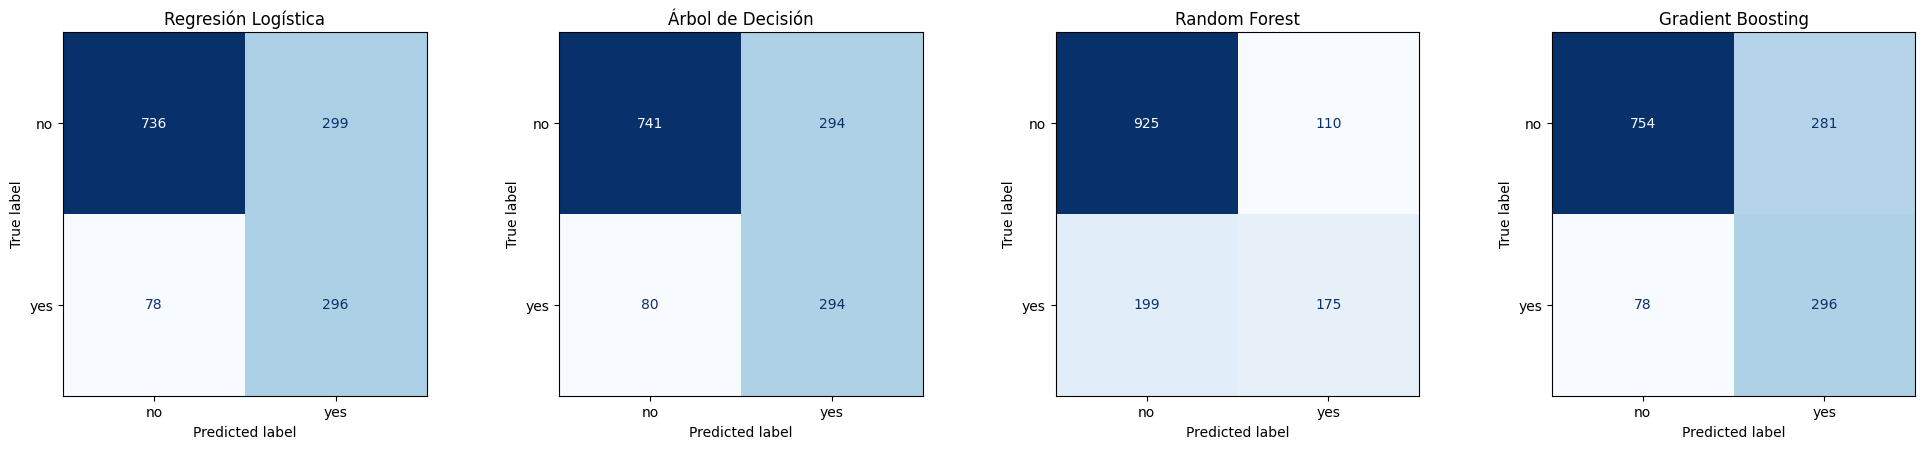

In [54]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (nombre, pred) in zip(axes, predicciones.items()):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["no", "yes"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(nombre)
plt.tight_layout()
plt.show()


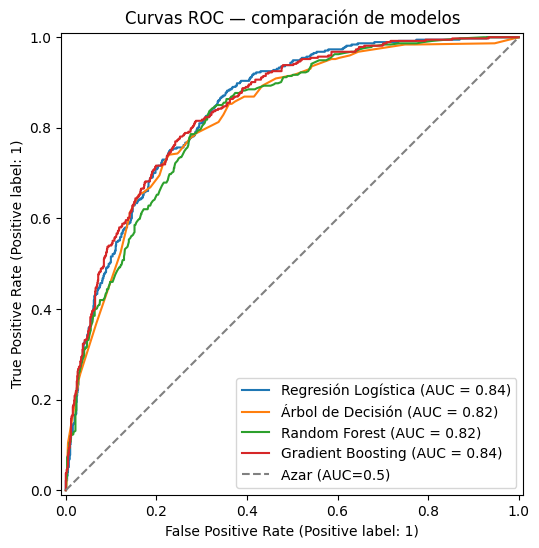

In [55]:
fig, ax = plt.subplots(figsize=(7, 6))
for nombre, proba in probabilidades.items():
    RocCurveDisplay.from_predictions(y_test, proba, name=nombre, ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar (AUC=0.5)")
ax.set_title("Curvas ROC — comparación de modelos")
ax.legend()
plt.show()

In [56]:
resultados_df.sort_values("ROC_AUC", ascending=False)

,Accuracy,Precision,Recall,F1,ROC_AUC
Modelo,,,,,
Gradient Boosting,0.745,0.513,0.791,0.623,0.843
Regresión Logística,0.732,0.497,0.791,0.611,0.842
Árbol de Decisión,0.735,0.500,0.786,0.611,0.824
Random Forest,0.781,0.614,0.468,0.531,0.824


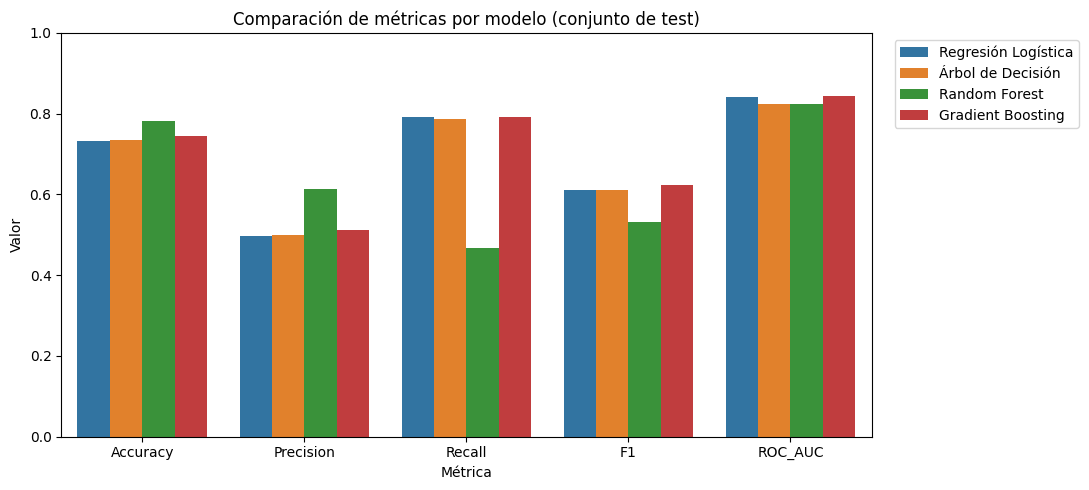

In [57]:
resultados_plot = resultados_df.reset_index().melt(id_vars="Modelo", var_name="Métrica", value_name="Valor")

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=resultados_plot, x="Métrica", y="Valor", hue="Modelo", ax=ax)
ax.set_title("Comparación de métricas por modelo (conjunto de test)")
ax.set_ylim(0, 1)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [58]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_resultados = []
for nombre, modelo in modelos.items():
    pipe_cv = construir_pipeline(modelo)
    cv = cross_validate(pipe_cv, X, y, cv=skf, scoring=["roc_auc", "f1", "accuracy"])
    cv_resultados.append({
        "Modelo": nombre,
        "ROC_AUC (media)": cv["test_roc_auc"].mean(),
        "ROC_AUC (std)": cv["test_roc_auc"].std(),
        "F1 (media)": cv["test_f1"].mean(),
        "Accuracy (media)": cv["test_accuracy"].mean()
    })

cv_df = pd.DataFrame(cv_resultados).set_index("Modelo").round(3)
cv_df.sort_values("ROC_AUC (media)", ascending=False)

,ROC_AUC (media),ROC_AUC (std),F1 (media),Accuracy (media)
Modelo,,,,
Gradient Boosting,0.846,0.011,0.584,0.802
Regresión Logística,0.845,0.012,0.625,0.745
Random Forest,0.826,0.012,0.546,0.789
Árbol de Decisión,0.820,0.007,0.610,0.728


**Justificación:** el modelo seleccionado combina el mejor ROC-AUC promedio en validación cruzada
con una desviación estándar baja (buena estabilidad entre folds) y un desempeño competitivo en
precisión/recall sobre el conjunto de test.

In [59]:
mejor_modelo_nombre = cv_df.sort_values("ROC_AUC (media)", ascending=False).index[0]
print(f"Modelo seleccionado: {mejor_modelo_nombre}")

mejor_pipeline = pipelines[mejor_modelo_nombre]

Modelo seleccionado: Gradient Boosting


Modelo final: Gradient Boosting

              precision    recall  f1-score   support

          no       0.91      0.73      0.81      1035
         yes       0.51      0.79      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



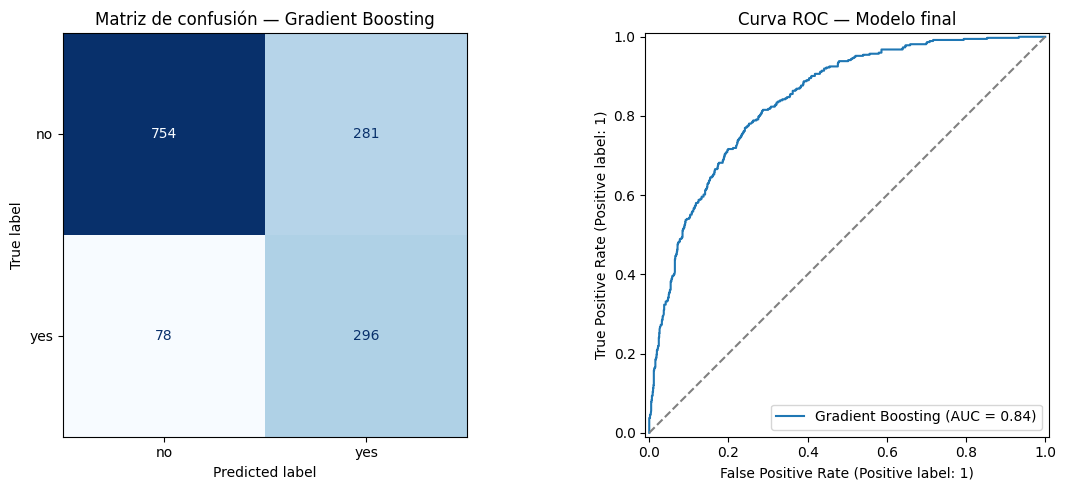

ROC-AUC final: 0.843


In [60]:
pred_final = predicciones[mejor_modelo_nombre]
proba_final = probabilidades[mejor_modelo_nombre]

print(f"Modelo final: {mejor_modelo_nombre}\n")
print(classification_report(y_test, pred_final, target_names=["no", "yes"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm = confusion_matrix(y_test, pred_final)
ConfusionMatrixDisplay(cm, display_labels=["no", "yes"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Matriz de confusión — {mejor_modelo_nombre}")

RocCurveDisplay.from_predictions(y_test, proba_final, name=mejor_modelo_nombre, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("Curva ROC — Modelo final")
plt.tight_layout()
plt.show()

print("ROC-AUC final:", round(roc_auc_score(y_test, proba_final), 3))

Analizamos qué variables aportan más al modelo final, recuperando los nombres de las columnas
generadas tras el *one-hot encoding*.

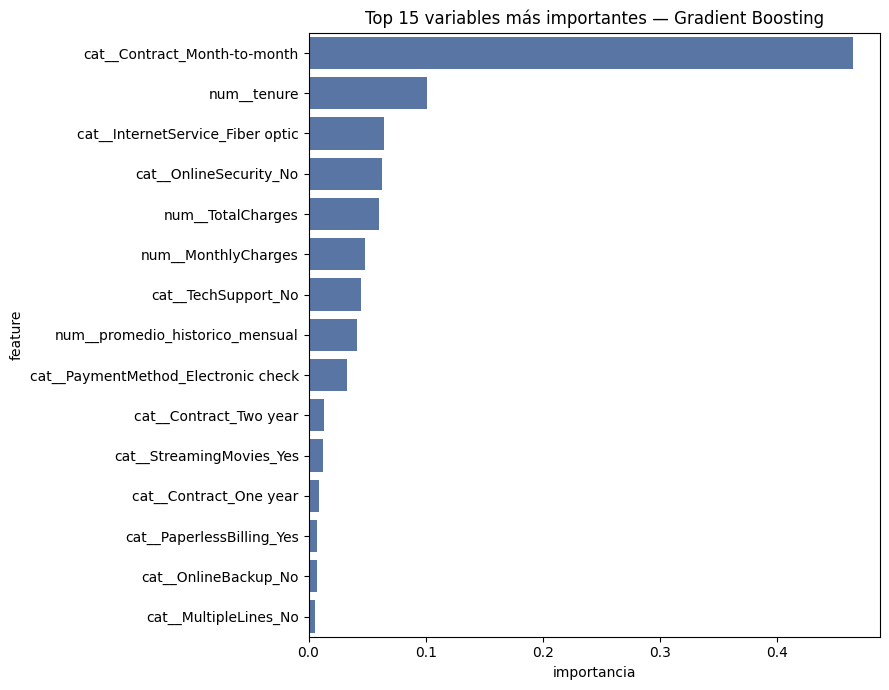

In [61]:
modelo_final = mejor_pipeline.named_steps["modelo"]
nombres_features = mejor_pipeline.named_steps["preprocesamiento"].get_feature_names_out()

if hasattr(modelo_final, "feature_importances_"):
    importancias = modelo_final.feature_importances_
elif hasattr(modelo_final, "coef_"):
    importancias = np.abs(modelo_final.coef_[0])
else:
    importancias = None

if importancias is not None:
    fi_df = pd.DataFrame({
        "feature": nombres_features,
        "importancia": importancias
    }).sort_values("importancia", ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.barplot(data=fi_df, x="importancia", y="feature", color="#4C72B0", ax=ax)
    ax.set_title(f"Top 15 variables más importantes — {mejor_modelo_nombre}")
    plt.tight_layout()
    plt.show()

    fi_df

# 🎯 **Conclusión Final y Recomendaciones**

El análisis confirma que es posible construir un modelo de clasificación que discrimina, de forma razonable, entre los clientes con mayor y menor probabilidad de abandonar la compañía (Churn), lo cual es clave para que el equipo de retención pueda actuar proactivamente antes de que el cliente finalice su relación con la empresa.

Los hallazgos principales son:

* **El tipo de contrato es el factor más determinante:** Los clientes con contratos mes a mes (*Month-to-month*) presentan una propensión al abandono sustancialmente mayor en comparación con aquellos comprometidos a mediano y largo plazo (1 o 2 años).
* **La antigüedad del cliente (*tenure*) es crítica:** El primer año de servicio representa el período de mayor riesgo de fuga. A mayor tiempo de permanencia, la lealtad se consolida y la probabilidad de cancelación disminuye drásticamente.
* **El costo y la tecnología influyen en la salida:** Los usuarios con el servicio de fibra óptica (*Fiber optic*) y con cargos mensuales (*MonthlyCharges*) elevados registran tasas de deserción muy altas, lo que sugiere una fuerte sensibilidad al precio y posibles problemas de relación valor-costo en ese segmento.
* **El método de pago automático fomenta la retención:** Los clientes que utilizan formas de pago manuales como el cheque electrónico (*Electronic check*) muestran una tasa de fuga muy superior a aquellos adheridos a débito automático o tarjeta de crédito.
* **La falta de servicios de seguridad incrementa el riesgo:** La ausencia de soporte adicional como seguridad en línea (*OnlineSecurity*) o soporte técnico (*TechSupport*) se asocia de forma directa con un aumento en la probabilidad de Churn.
* **El desbalance de clases exige un enfoque robusto:** Con solo un ~26.5% de clientes que cancelaron, el uso de técnicas de balanceo (*sample weights*) y la optimización de métricas orientadas al negocio como el Recall y el ROC-AUC (logrando un competitivo 0.843 con Gradient Boosting) garantiza identificar eficientemente al mayor porcentaje de clientes en riesgo sin generar falsas alarmas masivas.